In [58]:

!pip install pyspark

In [59]:

import pyspark
from pyspark.sql import SparkSession , DataFrame
from pyspark.ml.feature import StringIndexer, VectorAssembler , StandardScaler , ChiSqSelector
from pyspark.sql.functions import col
from pyspark.sql.functions import *
from pyspark.ml.stat import Correlation
from pyspark.sql.types import StructType, StructField, StringType, DoubleType , FloatType
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import LogisticRegression , LinearSVC ,OneVsRest ,NaiveBayes
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


 **Getting the Dataset**

Citation :
 fedesoriano. (January 2022). Stellar Classification Dataset - SDSS17. Retrieved [Date Retrieved] from https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17.



In [ ]:

from google.colab import drive
drive.mount('/content/drive' , force_remount = True)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-112-b9b4fbed11e4>", line 2, in <cell line: 2>
    drive.mount('/content/drive' , force_remount = True)
  File "/usr/local/lib/python3.10/dist-packages/google/colab/drive.py", line 103, in mount
    return _mount(
  File "/usr/local/lib/python3.10/dist-packages/google/colab/drive.py", line 259, in _mount
    case = d.expect([
  File "/usr/local/lib/python3.10/dist-packages/pexpect/spawnbase.py", line 343, in expect
    return self.expect_list(compiled_pattern_list,
  File "/usr/local/lib/python3.10/dist-packages/pexpect/spawnbase.py", line 372, in expect_list
    return exp.expect_loop(timeout)
  File "/usr/local/lib/python3.10/dist-packages/pexpect/expect.py", line 171, in expect_loop
    time.sleep(self.spawn.delayafterread)
KeyboardInterrupt

During handling of the abov

In [61]:
# fedesoriano. (January 2022). Stellar Classification Dataset - SDSS17.
# Retrieved [2023-05-25] from https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17.

import os
os.chdir('/content/drive/MyDrive/Project-Datasets')
! ls

star_classification.csv


**Making The Spark Data Frame**

In [62]:
spark = SparkSession.builder.getOrCreate()
DF = spark.read.csv('star_classification.csv' , header= True , inferSchema = True )

In [63]:
print(type(DF))
print(DF.dtypes)

<class 'pyspark.sql.dataframe.DataFrame'>
[('obj_ID', 'double'), ('alpha', 'double'), ('delta', 'double'), ('u', 'double'), ('g', 'double'), ('r', 'double'), ('i', 'double'), ('z', 'double'), ('run_ID', 'int'), ('rerun_ID', 'int'), ('cam_col', 'int'), ('field_ID', 'int'), ('spec_obj_ID', 'double'), ('class', 'string'), ('redshift', 'double'), ('plate', 'int'), ('MJD', 'int'), ('fiber_ID', 'int')]


In [64]:
# First 5 rows of tha dataset and the shape of it
DF.show(n = 5 , truncate = False)
print("The shape of the dataset is {:d} rows with {:d} columns".format(DF.count(), len(DF.columns)))


+----------------------+----------------+------------------+--------+--------+--------+--------+--------+------+--------+-------+--------+---------------------+------+---------+-----+-----+--------+
|obj_ID                |alpha           |delta             |u       |g       |r       |i       |z       |run_ID|rerun_ID|cam_col|field_ID|spec_obj_ID          |class |redshift |plate|MJD  |fiber_ID|
+----------------------+----------------+------------------+--------+--------+--------+--------+--------+------+--------+-------+--------+---------------------+------+---------+-----+-----+--------+
|1.23766096132774323E18|135.6891066036  |32.4946318397087  |23.87882|22.2753 |20.39501|19.16573|18.79371|3606  |301     |2      |79      |6.5437773692951818E18|GALAXY|0.6347936|5812 |56354|171     |
|1.23766487995115136E18|144.826100550256|31.2741848944939  |24.77759|22.83188|22.58444|21.16812|21.61427|4518  |301     |5      |119     |1.1760142036707334E19|GALAXY|0.779136 |10445|58158|427     |
|1.23

In [65]:
# Move the target class column to the last position (it is not mandatory , but it is more convenient for me)
from pyspark.sql.functions import col
column_names = DF.columns
target_column_name = "class"
column_names.remove(target_column_name)
column_names.append(target_column_name)
# Reorder the columns in the DataFrame
DF = DF.select(*[col(column_name) for column_name in column_names])


In [66]:
DF.show(n = 5 , truncate = False)

+----------------------+----------------+------------------+--------+--------+--------+--------+--------+------+--------+-------+--------+---------------------+---------+-----+-----+--------+------+
|obj_ID                |alpha           |delta             |u       |g       |r       |i       |z       |run_ID|rerun_ID|cam_col|field_ID|spec_obj_ID          |redshift |plate|MJD  |fiber_ID|class |
+----------------------+----------------+------------------+--------+--------+--------+--------+--------+------+--------+-------+--------+---------------------+---------+-----+-----+--------+------+
|1.23766096132774323E18|135.6891066036  |32.4946318397087  |23.87882|22.2753 |20.39501|19.16573|18.79371|3606  |301     |2      |79      |6.5437773692951818E18|0.6347936|5812 |56354|171     |GALAXY|
|1.23766487995115136E18|144.826100550256|31.2741848944939  |24.77759|22.83188|22.58444|21.16812|21.61427|4518  |301     |5      |119     |1.1760142036707334E19|0.779136 |10445|58158|427     |GALAXY|
|1.23

**Removing Duplicate Rows and Nulls**

In [67]:
# Removing Duplicate Rows
duplicate_rows = DF.groupby(DF.columns).count().where(col("count") > 1)
DF = DF.dropDuplicates()
DF.printSchema()

root
 |-- obj_ID: double (nullable = true)
 |-- alpha: double (nullable = true)
 |-- delta: double (nullable = true)
 |-- u: double (nullable = true)
 |-- g: double (nullable = true)
 |-- r: double (nullable = true)
 |-- i: double (nullable = true)
 |-- z: double (nullable = true)
 |-- run_ID: integer (nullable = true)
 |-- rerun_ID: integer (nullable = true)
 |-- cam_col: integer (nullable = true)
 |-- field_ID: integer (nullable = true)
 |-- spec_obj_ID: double (nullable = true)
 |-- redshift: double (nullable = true)
 |-- plate: integer (nullable = true)
 |-- MJD: integer (nullable = true)
 |-- fiber_ID: integer (nullable = true)
 |-- class: string (nullable = true)



**Cheking fo NULLs**

In [68]:
DF_Pandas = DF.toPandas()
DF_Pandas.info()
# Checking if any values are null:
DF_Pandas.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int32  
 9   rerun_ID     100000 non-null  int32  
 10  cam_col      100000 non-null  int32  
 11  field_ID     100000 non-null  int32  
 12  spec_obj_ID  100000 non-null  float64
 13  redshift     100000 non-null  float64
 14  plate        100000 non-null  int32  
 15  MJD          100000 non-null  int32  
 16  fiber_ID     100000 non-null  int32  
 17  class        100000 non-null  object 
dtypes: float64(10), int32(7),

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
redshift       0
plate          0
MJD            0
fiber_ID       0
class          0
dtype: int64

In [69]:
DF_Pandas.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [70]:
# "rerun_ID" column values are the same (301) for all rows. It can be dropped in column.
# "spec_obj_ID" is individual for every entry, it can be dropped as well.

DF_Pandas.drop(["rerun_ID","spec_obj_ID"], axis=1, inplace=True)

In [71]:
DF_Pandas.head().T

,0,1,2,3,4
obj_ID,1237662341092999936.0,1237666210854535936.0,1237678860075598336.0,1237663478726525952.0,1237665126933856768.0
alpha,253.521744,267.627277,344.519136,343.864358,186.468156
delta,19.057524,25.410781,12.377171,-0.230266,33.763406
u,21.94553,21.8857,22.54692,23.41644,23.22562
g,21.44538,20.22803,21.53392,23.05205,21.81247
r,19.54981,19.60719,21.47066,22.15027,19.98678
i,18.87251,19.38448,20.97943,21.36819,19.02708
z,18.44153,19.24491,20.6388,21.17727,18.54597
run_ID,3927,4828,7773,4192,4576
cam_col,4,4,5,3,1


**Visualizing the 3 Classes counts**

<Axes: xlabel='class', ylabel='count'>

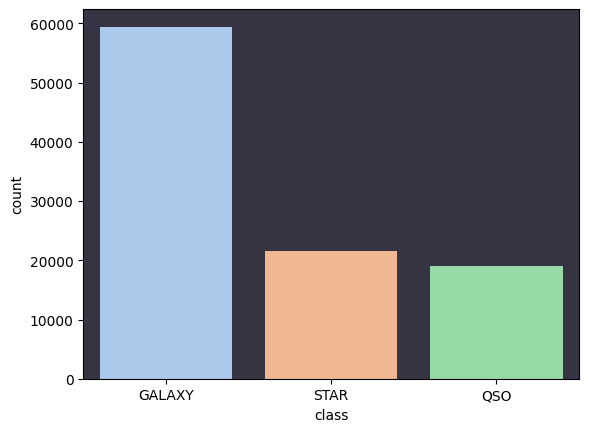

In [72]:
# Visualizing the data
sb.countplot(x = DF_Pandas["class"] , palette="pastel")

In [73]:
 import plotly.express as ex
 ex.pie(DF_Pandas,names='class',title='Propotion Of Different Class',hole=0.25)

**Visualizing the Features**

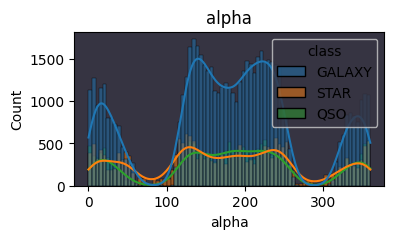

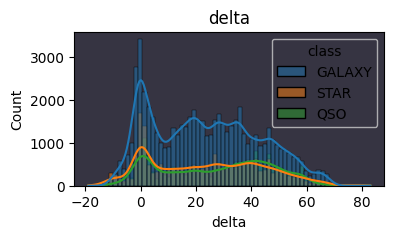

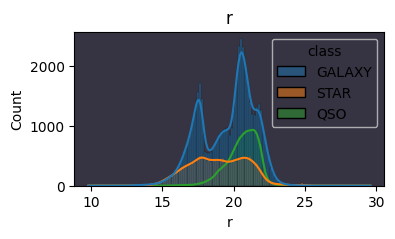

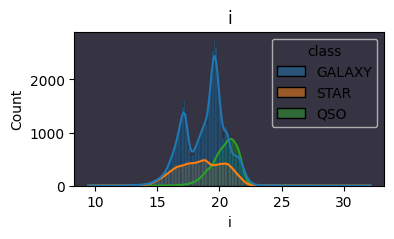

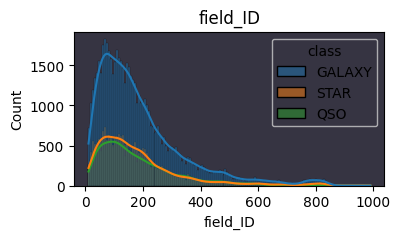

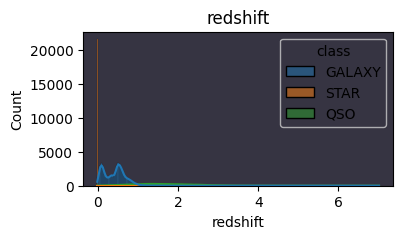

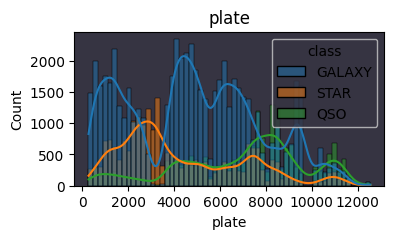

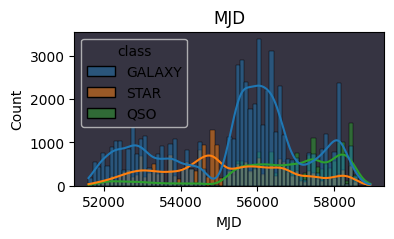

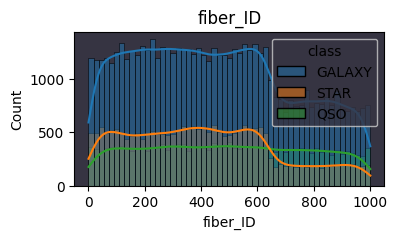

In [74]:
for column in ['alpha' , 'delta' , 'r' , 'i' , 'field_ID' , 'redshift', 'plate', 'MJD', 'fiber_ID'] :
  plt.figure(figsize = (4,2))
  sb.histplot(data = DF_Pandas, x = column , kde = True , hue = "class" )
  plt.title(column)
  plt.show()

**Distribution of each Feature among 3 Classes**

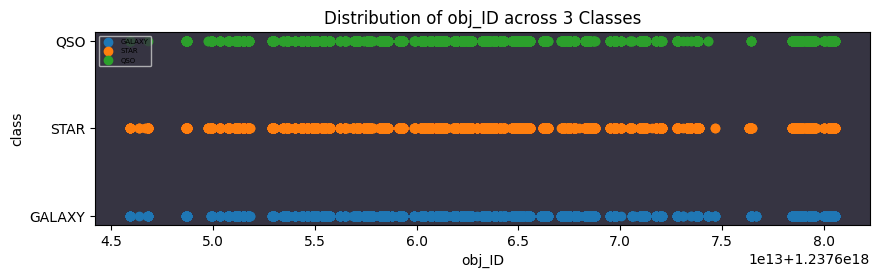

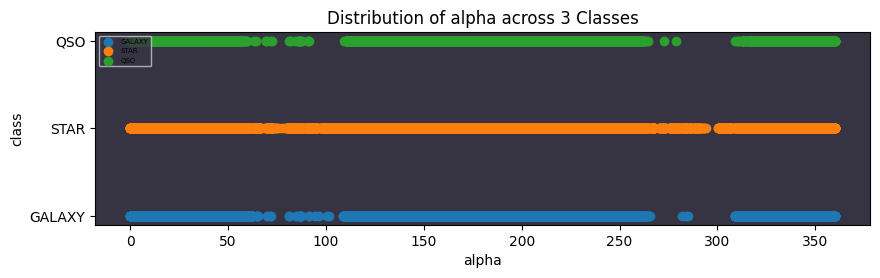

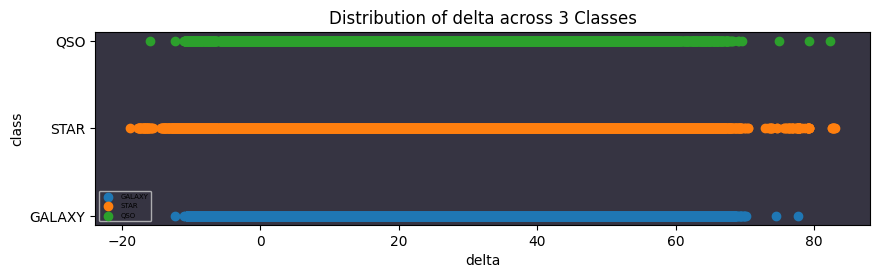

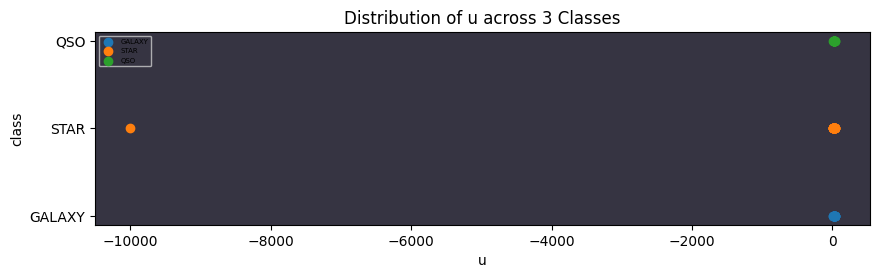

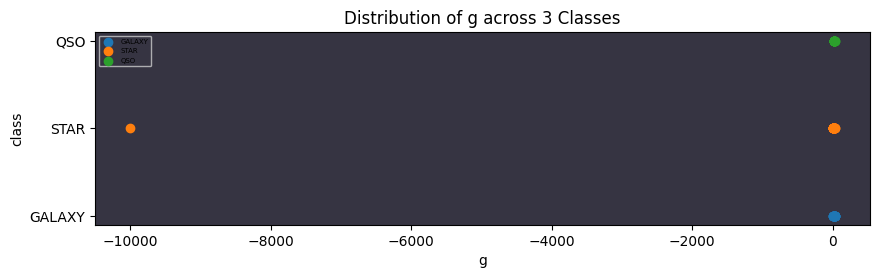

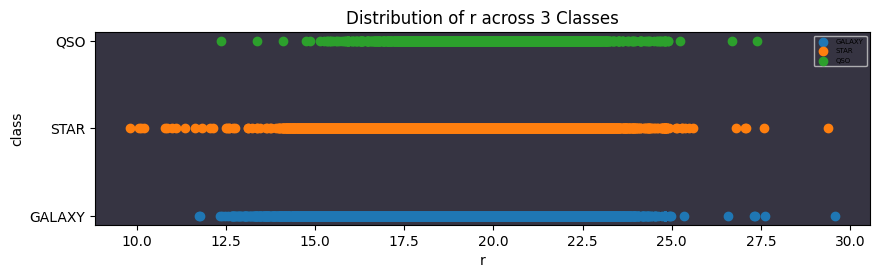

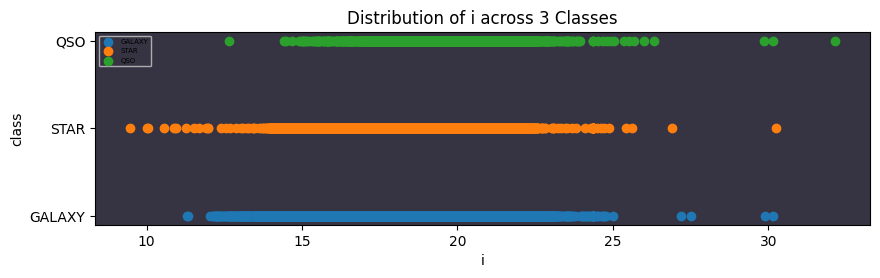

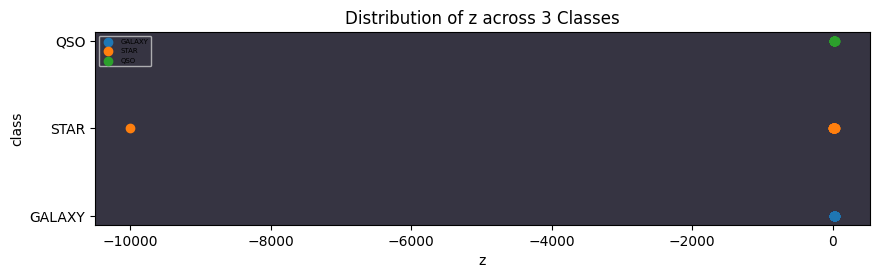

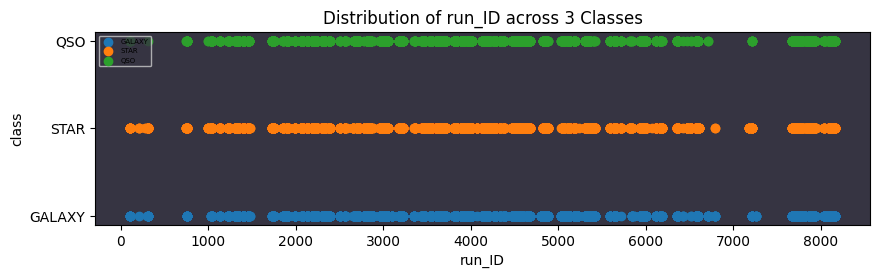

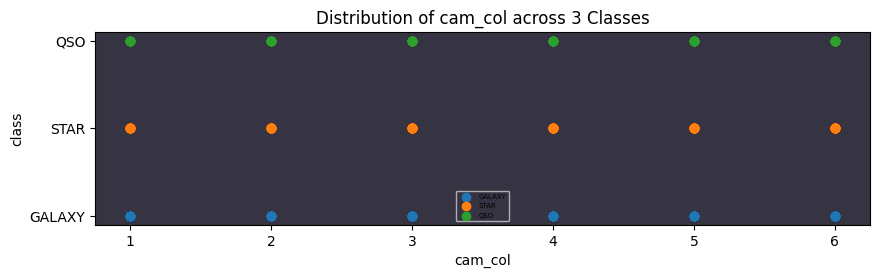

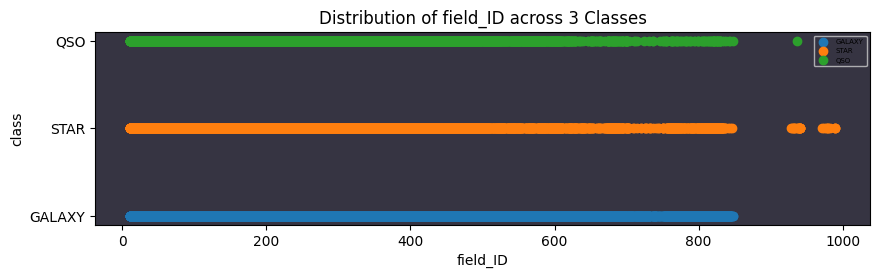

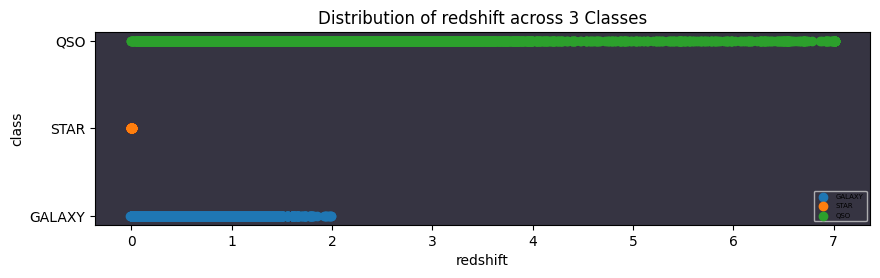

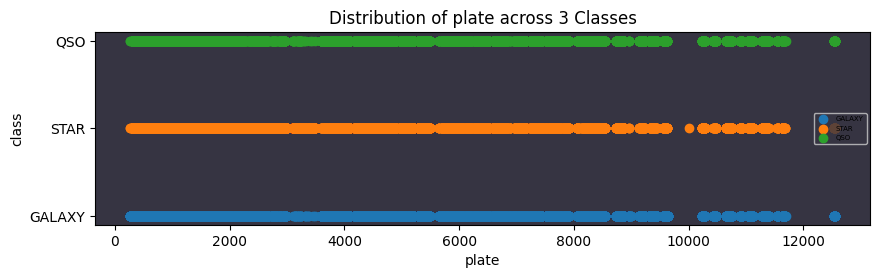

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



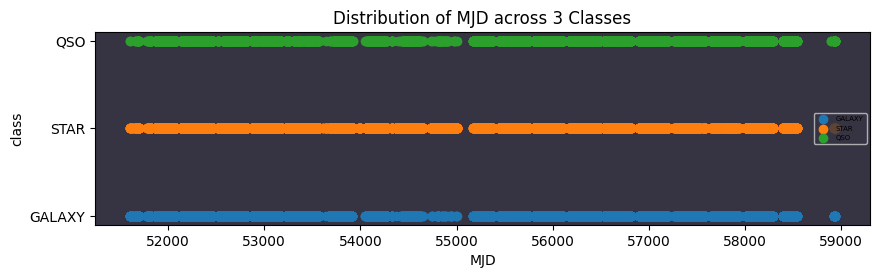

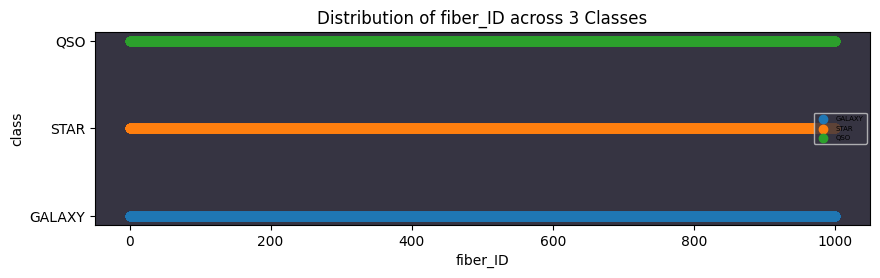

In [75]:
# Distribution of each feature across 3 classes.

# Select the features and class column
features = ['obj_ID' , 'alpha' , 'delta' ,  'u' , 'g' , 'r' ,  'i' , 'z' , 'run_ID' , 'cam_col' , 'field_ID' , 'redshift' , 'plate' , 'MJD' , 'fiber_ID']
class_column = 'class'

# Loop through each feature
for feature in features:
    plt.figure(figsize=(10, 2.5))
    # Create a scatter plot for each class
    for class_value in DF_Pandas[class_column].unique():
        # Select data points for the current class
        data_points = DF_Pandas[DF_Pandas[class_column] == class_value]

        # Plot the feature against the class
        plt.scatter(data_points[feature], data_points[class_column], label=class_value)

    # Set plot title and labels
    plt.title(f'Distribution of {feature} across 3 Classes')
    plt.xlabel(feature)
    plt.ylabel(class_column)

    # Add legend
    plt.legend(fontsize = 5)

    # Show the plot
    plt.show()

<ipython-input-76-d76095d5ab56>:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



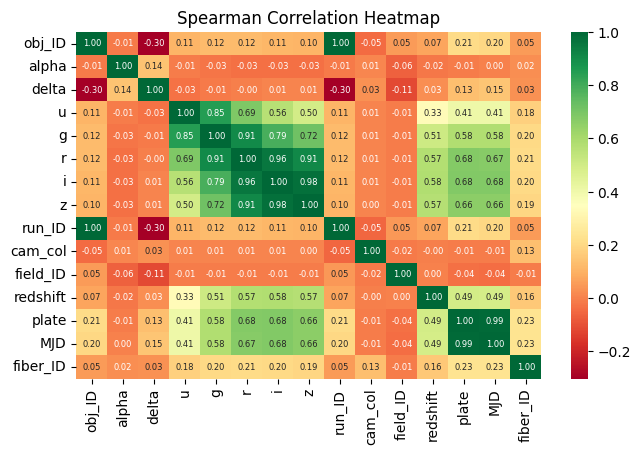

In [76]:

# Calculate the correlation matrix
df_corr = DF_Pandas.corr(method="spearman")

# Create a figure and axes
f, ax = plt.subplots(figsize=(7.5, 4.5))

# Generate the heatmap
sb.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdYlGn', annot_kws={'size': 6}, ax=ax)

# Set plot title
plt.title('Spearman Correlation Heatmap')

# Show the plot
plt.show()

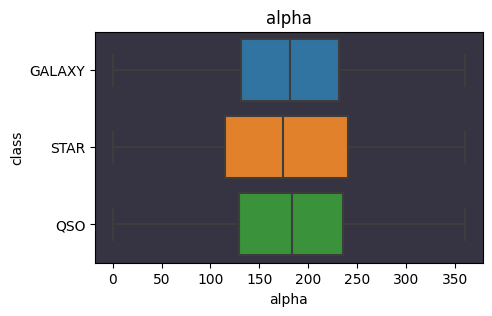

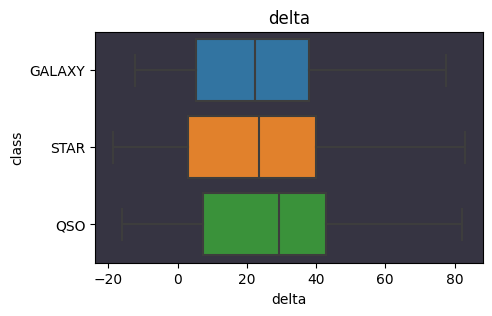

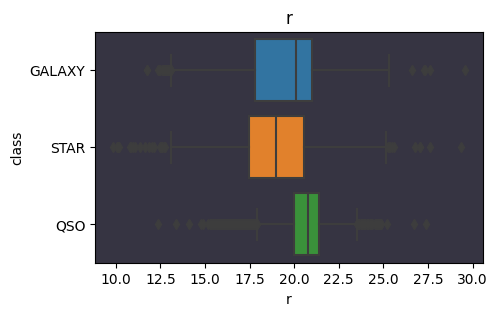

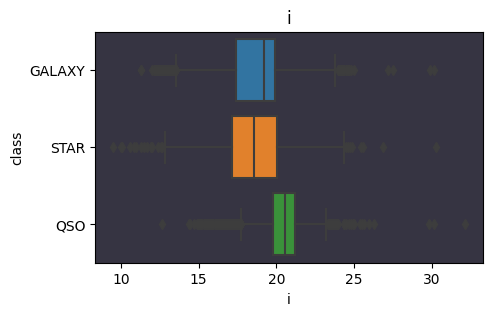

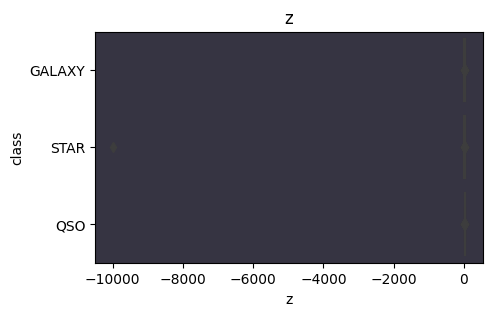

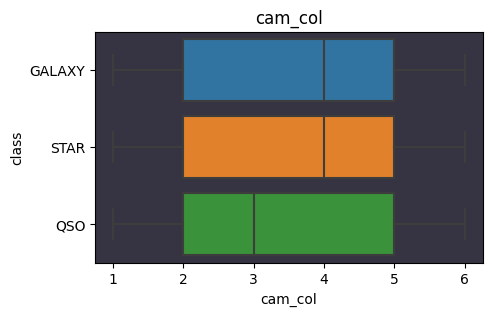

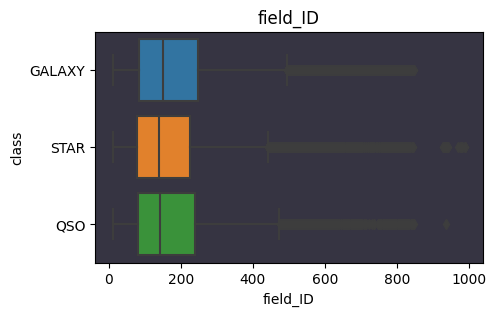

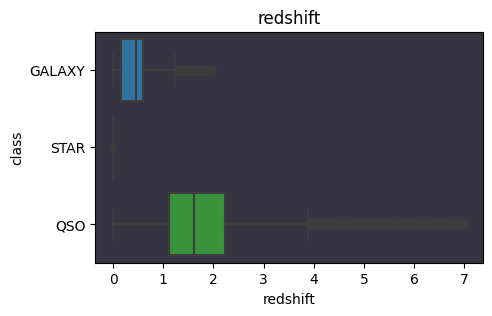

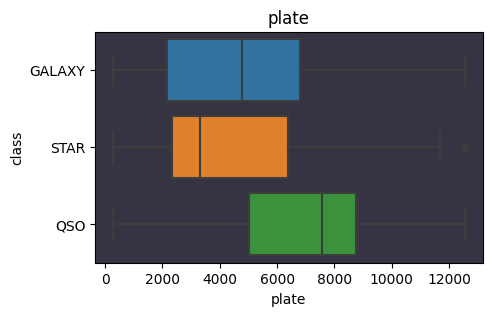

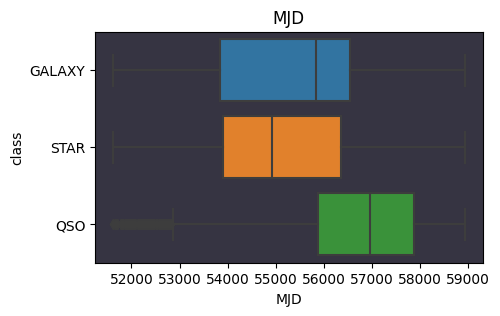

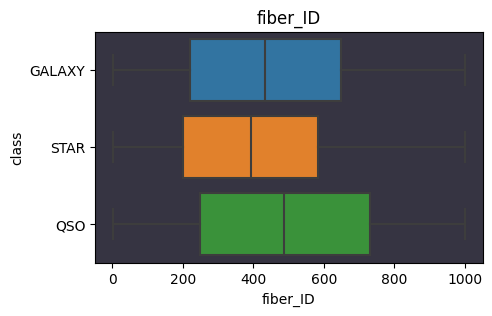

In [77]:
# Galaxies are more distinguished compared to Stars and Quasars (QSO)
# I want to plot 3 classes according to these features to identify distinctive features among them

Star_QSO = DF_Pandas[(DF_Pandas["class"]=="GALAXY") | (DF_Pandas["class"]=="STAR") | (DF_Pandas["class"]=="QSO")]
for column in ['alpha', 'delta','r', 'i', 'z' ,'cam_col','field_ID','redshift', 'plate', 'MJD', 'fiber_ID']:
  plt.figure(figsize=(5,3))
  plt.title(column)
  sb.boxplot(data = Star_QSO , x = column , y = "class" , )
  plt.show()

**Dropping some Features that are irrelevant in Classification**


In [78]:
# Using the plots , I am going to drop some features
DF_Pandas.drop(["obj_ID" , "run_ID" , "cam_col" , "field_ID" , "fiber_ID"], axis=1, inplace=True)

**Removing the Outliers**

In [79]:
# First : it is now clear attributes like  "r" , "i" and specially "redshift" will play a key role to differentiate these two classes
# Second : There are a lot of outliers and we need to remove them from our dataset

Shape01 = DF_Pandas.shape

for i in DF_Pandas.select_dtypes(include = "number").columns :
  Q1 = DF_Pandas[i].quantile(0.25)
  Q3 = DF_Pandas[i].quantile(0.75)
  DQ = Q3 - Q1
  lower_bound = Q1 - (1.5 * DQ)
  upper_bound = Q3 + (1.5 * DQ)

  min_index = DF_Pandas[DF_Pandas[i] < lower_bound ].index
  max_index = DF_Pandas[DF_Pandas[i] > upper_bound ].index
  DF_Pandas.drop(min_index , inplace = True)
  DF_Pandas.drop(max_index , inplace = True)

Shape02 = DF_Pandas.shape
outlier_num = Shape01[0] - Shape02[0]

print (" Number of Outliers that have been Removed :" , outlier_num )

 Number of Outliers that have been Removed : 9400


**Label Encoding**

In [80]:
# Creating a StringIndexer to index the 'class' column

DF_S = spark.createDataFrame(DF_Pandas) # Converting Pandas DataFrame to Spark DataFrame
indexer = StringIndexer(inputCol="class", outputCol="indexed_class")
indexed_DF = indexer.fit(DF_S).transform(DF_S)


# **Startifying the imbalanced Data**

The data is very imbalanced and GALAXY samples are much higher than the other 2 samples.
But instead of "undersampling or oversampling",
I will use " startify " method to split the data according to the current proportion of classes.

For "stratified" sampling and splitting, I could use Startify parameter in "train_test_split" Function in sklearn library ,
but it can not be used for Pyspark DataFrames since there is not such a function or parameter in Pyspark.
So we have to implement "stratified" sampling in an other way using Pyspark Data Frames:



In [81]:
# Calculating the class proportions:

class_proportions = (
    indexed_DF.groupBy("indexed_class")
    .count()
    .withColumn("proportion", col("count") / indexed_DF.count())
    .orderBy("indexed_class")
    .select("proportion")
    .rdd.flatMap(lambda x: x)
    .collect()
)


# Calculate the desired counts for each class
total_count = indexed_DF.count()
class_counts = [int(prop * total_count) for prop in class_proportions]

# Create a filter condition for each class
class_filters = [col("indexed_class") == i for i in range(len(class_proportions))]

# Applying stratified splitting
dfs = []
for i in range(len(class_proportions)):
    filtered_data = indexed_DF.filter(class_filters[i])
    train_proportion = 0.8 * class_proportions[i]  # 80% for training
    test_proportion = class_proportions[i] - train_proportion
    class_train_data, class_test_data = filtered_data.randomSplit(
        [train_proportion, test_proportion] , seed=42
    )
    dfs.append((class_train_data, class_test_data))

# Combine the train and test datasets for each class
train_data = dfs[0][0]
test_data = dfs[0][1]
for i in range(1, len(class_proportions)):
    train_data = train_data.union(dfs[i][0])
    test_data = test_data.union(dfs[i][1])




# **Random Forest**
To find the best " number of trees " and " max depth" , first, I ploted the accuracy with different values for these Hyperparameters to get an idea of the values.
Then, I used K-Fold Cross Validation to find the best combination of these two Hyperparameters.
( After I found the best set of values, I commented that out because it takes quite a while to execute that section)

**Plotting Random Forest accuracy with different Number of Trees**




In [82]:
# Implementing Random Forest

accuracy_rf = list()

# Specifying the feature columns
feature_columns = [ 'alpha' , 'delta' ,  'u' , 'g' , 'r' ,  'i' , 'z'  , 'redshift' , 'plate' , 'MJD' ]

# Creating a VectorAssembler to combine the feature columns into a single vector column
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Creating a RandomForestClassifier
for NumT in range(40,101,10):
  random_forest = RandomForestClassifier(labelCol="indexed_class", featuresCol="features" , numTrees = NumT)
  # Create a pipeline with VectorAssembler and RandomForestClassifier
  pipeline_rf = Pipeline(stages=[vector_assembler, random_forest])
  # Fit the pipeline on the training data
  model_rf = pipeline_rf.fit(train_data)
  # Make predictions on the test data
  predictions_rf = model_rf.transform(test_data)


  # Computing evaluation metrics for Random Forest  : Accuracy
  evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
  accuracy_rf.append(evaluator.evaluate(predictions_rf))


accuracy_rf

[0.9582605756773503,
 0.9573029910437673,
 0.9581479186616346,
 0.9590491747873598,
 0.9580915901537769,
 0.958654875232355,
 0.9581479186616346]

[]

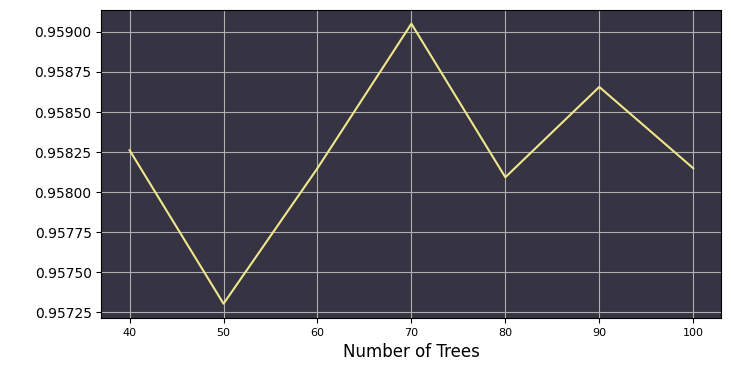

In [83]:
figure_labels=['40','50','60','70','80','90','100']

plt.figure(figsize = (8,4))
plt.rcParams ['axes.facecolor'] = '#363442'
plt.plot(figure_labels, accuracy_rf, color='khaki')
plt.xlabel('Number of Trees', color = 'black', size = 12)
plt.ylabel('Accuracy', color = 'white', size = 14)
plt.xticks(color = 'black', size = 8)
plt.grid()

plt.plot()


**Plotting Random Forest accuracy with different Max Depths**


In [84]:
accuracies = list()

for MaxDepth in range(10, 31, 10):
  # Create a Random Forest classifier with the current maxDepth
  random_forest = RandomForestClassifier(labelCol="indexed_class", featuresCol="features", maxDepth=MaxDepth)
  # Create a pipeline with VectorAssembler and RandomForestClassifier
  pipeline_rf = Pipeline(stages=[vector_assembler, random_forest])
  # Fit the pipeline on the training data
  model_rf = pipeline_rf.fit(train_data)
  # Make predictions on the test data
  predictions_rf = model_rf.transform(test_data)
  # Compute evaluation metrics for Random Forest: Accuracy
  evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
  accuracy = evaluator.evaluate(predictions_rf)
  # Append the accuracy to the accuracies list
  accuracies.append(accuracy)

accuracies

[0.9700332338196361, 0.9721173886103757, 0.9718920745789444]

[]

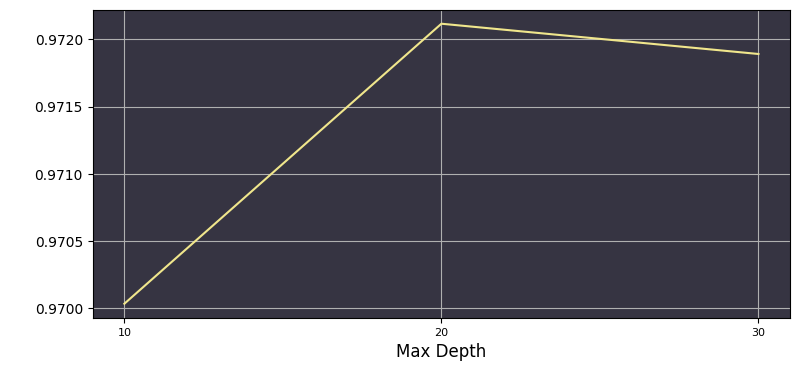

In [85]:
figure_labels=['10','20','30']

plt.figure(figsize = (9,4))
plt.rcParams ['axes.facecolor'] = '#363442'
plt.plot(figure_labels, accuracies, color='khaki')
plt.xlabel('Max Depth', color = 'black', size = 12)
plt.ylabel('Accuracy', color = 'white', size = 14)
plt.xticks(color = 'black', size = 8)
plt.grid()

plt.plot()

 **Finding the best combination of " number of trees " and  " max depth " for Random Forest**

The result is :


*   Best maxDepth value: 10
*   Best number of Trees value: 90

*   Accuracy : 97.12 %






In [86]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Define the Random Forest classifier
random_forest = RandomForestClassifier(labelCol="indexed_class", featuresCol="features")

# Create a new pipeline with VectorAssembler and RandomForestClassifier
pipeline_rf = Pipeline(stages=[vector_assembler, random_forest])

# Define the parameter grid for maxDepth and numTrees
param_grid = (ParamGridBuilder()
    .addGrid(random_forest.maxDepth, range(5, 11, 5))
    .addGrid(random_forest.numTrees, [70,80,90])
    .build())

# Create the cross-validator
cross_validator = CrossValidator(estimator=pipeline_rf,
                                estimatorParamMaps=param_grid,
                                evaluator=MulticlassClassificationEvaluator(labelCol="indexed_class",
                                                                            predictionCol="prediction",
                                                                            metricName="accuracy"),
                                numFolds=5)  # Set the number of folds for cross-validation

# Fit the cross-validator on the training data
cv_model = cross_validator.fit(train_data)

# Get the best model from cross-validation
best_model = cv_model.bestModel

# Get the best maxDepth and numTrees values from the best model
best_maxDepth = best_model.stages[-1].getMaxDepth()
best_numTrees = best_model.stages[-1].getNumTrees

# Print the best maxDepth and numTrees values
print("Best maxDepth value: ", best_maxDepth)
print("Best numTrees value: ", best_numTrees)

# Use the best model to make predictions on the test data
predictions_rf = best_model.transform(test_data)

# Compute evaluation metrics for Random Forest: Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class",
                                              predictionCol="prediction",
                                              metricName="accuracy")
accuracy = evaluator.evaluate(predictions_rf)

# Print the accuracy
print("Accuracy: {:.2%}".format(accuracy))


**Building the Random Forest model with the best Hyperparameters**

In [87]:
# Define the Random Forest classifier after knowing the best maxDepth and number of Trees
random_forest = RandomForestClassifier(labelCol="indexed_class", featuresCol="features", maxDepth=10 , numTrees=90)

# Create a new pipeline with VectorAssembler and RandomForestClassifier
pipeline_rf = Pipeline(stages=[vector_assembler, random_forest])
# Fit the pipeline on the training data
model_rf = pipeline_rf.fit(train_data)
# Make predictions on the test data
predictions_rf = model_rf.transform(test_data)

# Compute evaluation metrics for Random Forest: Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_rf)

print("Accuracy: {:.2%}".format(accuracy))


Accuracy: 97.09%


**Computing evaluation metrics : Precision, Recall and F1-score - Random Forest**

In [88]:
# Random Forest - Computing evaluation metrics : precision, recall and F1-score

predictionAndLabels = predictions_rf.select("prediction", "indexed_class").rdd
metrics = MulticlassMetrics(predictionAndLabels)
labels = predictionAndLabels.map(lambda x: x[1]).distinct().collect()

print("Random Forest - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO \n")
for label in labels:
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    f1Score = metrics.fMeasure(label)

    print("Class: ", label)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1-Score: ", f1Score ,"\n")


/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:157: FutureWarning:

Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.



Random Forest - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO 

Class:  0.0
Precision:  0.9748932536293766
Recall:  0.9809245574841038
F1-Score:  0.9778996059619667 

Class:  1.0
Precision:  0.9727780362959516
Recall:  0.9990442054958184
F1-Score:  0.9857361782388305 

Class:  2.0
Precision:  0.9392550143266476
Recall:  0.8492227979274611
F1-Score:  0.8919727891156463 



**Confusion Matrix - Random Forest**

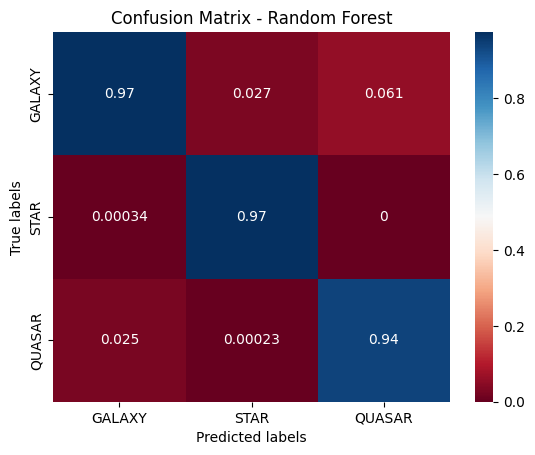

In [89]:
# Confusion Matrix (in %) - Random Forest
predictionAndLabels_rf = predictions_rf.select("prediction", "indexed_class").rdd.map(lambda row: (row.prediction, float(row.indexed_class)))
metrics_rf = MulticlassMetrics(predictionAndLabels_rf)
confumx_rf = metrics_rf.confusionMatrix()
confuarr_rf = confumx_rf.toArray()
confusionmatrix_rf = pd.DataFrame(confuarr_rf)
ax_rf = plt.subplot()
sb.heatmap(confusionmatrix_rf/np.sum(confusionmatrix_rf), annot=True, cmap='RdBu')
ax_rf.set_xlabel("Predicted labels")
ax_rf.set_ylabel("True labels")
ax_rf.set_title("Confusion Matrix - Random Forest")
ax_rf.xaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
ax_rf.yaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
plt.show()

**AUC - Random Forest**

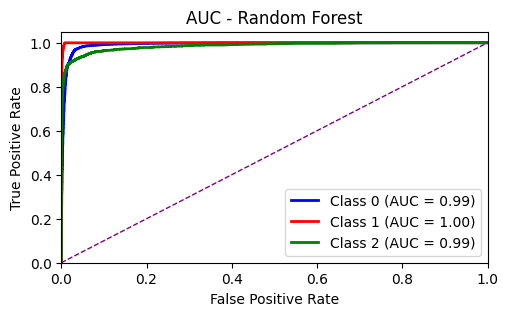

In [90]:
# Convert DataFrame to Pandas for computing ROC curve
predictions_pd = predictions_rf.select('indexed_class', 'probability').toPandas()

# Compute ROC curve and AUC for each class
n_classes = len(predictions_pd['indexed_class'].unique())
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    true_labels = (predictions_pd['indexed_class'] == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(true_labels, predictions_pd['probability'].apply(lambda x: float(x[i])))
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(5.5, 3) )
plt.rcParams ['axes.facecolor'] = 'white'
colors = ['blue', 'red', 'green']  # Customize colors for each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='purple', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC - Random Forest')
plt.legend(loc='lower right')
plt.show()

**Learning Curve - Random Forest**

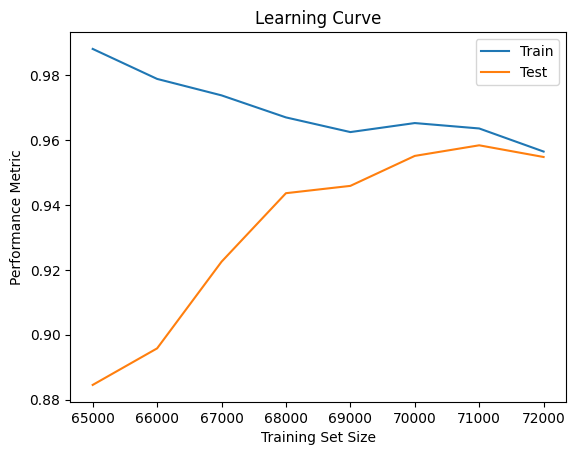

In [91]:
# Learning Curve

# Specifying the feature columns
feature_columns = [ 'alpha' , 'delta' ,  'u' , 'g' , 'r' ,  'i' , 'z'  , 'redshift' , 'plate' , 'MJD' ]

# Creating a VectorAssembler to combine the feature columns into a single vector column
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

random_forest = RandomForestClassifier(labelCol="indexed_class", featuresCol="features" )
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")

# Initialize arrays to store the training sizes and performance metrics
training_sizes = []
train_scores = []
test_scores = []
# Define the range of training set sizes to use
min_train_size = 65000
max_train_size = train_data.count()
step_size = 1000

# Iterate over different training set sizes
for train_size in range(min_train_size, max_train_size+1, step_size):
    # Select a subset of the training data
    subset_train_data = train_data.limit(train_size)

    pipeline_rf = Pipeline(stages=[vector_assembler, random_forest])
    # Fit the pipeline on the training data
    model_rf = pipeline_rf.fit(subset_train_data)

    # Make predictions on the training and test sets
    train_predictions = model_rf.transform(subset_train_data)
    test_predictions = model_rf.transform(test_data)

    # Evaluate the performance on both sets
    train_score = evaluator.evaluate(train_predictions)
    test_score = evaluator.evaluate(test_predictions)

    # Store the training size and performance metrics
    training_sizes.append(train_size)
    train_scores.append(train_score)
    test_scores.append(test_score)


# Convert the lists to numpy arrays for plotting

training_sizes = np.array(training_sizes)
train_scores = np.array(train_scores)
test_scores = np.array(test_scores)

# Plot the learning curve
plt.figure()
plt.plot(training_sizes, train_scores, label='Train')
plt.plot(training_sizes, test_scores, label='Test')
plt.xlabel('Training Set Size')
plt.ylabel('Performance Metric')
plt.title('Learning Curve')
plt.legend()
plt.show()


**Feature Importance - Random Forest**

In [92]:
# I want to know the importance of each feature in predictions in Random Forest

pipeline_model = pipeline_rf.fit(indexed_DF)

# Get the trained random forest model
model_rf = pipeline_model.stages[-1]

# Retrieve feature importances from the model
importances = model_rf.featureImportances.toArray()
importances = [float(x) for x in importances]

# Create a DataFrame to store feature names and importances
feature_importance_df = spark.createDataFrame(zip(indexed_DF.columns[:-1], importances), ['Feature', 'Importance_RandomForest'])

# Specify the data type of the 'Importance' field
feature_importance_df = feature_importance_df.withColumn('Importance_RandomForest', feature_importance_df['Importance_RandomForest'].cast(FloatType()))

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.orderBy('Importance_RandomForest', ascending=False)

# Show the feature importances
feature_importance_df.show()

+--------+-----------------------+
| Feature|Importance_RandomForest|
+--------+-----------------------+
|redshift|              0.7745003|
|       z|            0.060788523|
|       u|             0.05660757|
|       g|            0.030246533|
|       i|            0.022468092|
|   plate|            0.022283787|
|       r|            0.017775655|
|     MJD|            0.015070094|
|   alpha|           2.0885274E-4|
|   delta|           5.0605166E-5|
+--------+-----------------------+



**Decision Tree**

**Plotting Decision Tree accuracy with different max Depths**


In [93]:
# Decision Tree Classifier - Different maxDepths

accuracy_dt = list()

for i in range(5, 31, 5):
  decision_tree = DecisionTreeClassifier(labelCol="indexed_class", featuresCol="features" , maxDepth = i)
  # Create a new pipeline with VectorAssembler and DecisionTreeClassifier
  pipeline_dt = Pipeline(stages=[vector_assembler, decision_tree])
  # Fit the pipeline on the training data
  model_dt = pipeline_dt.fit(train_data)
  # Make predictions on the test data
  predictions_dt = model_dt.transform(test_data)

  # Computing evaluation metrics for Decision Tree : Accuracy
  evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
  accuracy_dt.append(evaluator.evaluate(predictions_dt))

accuracy_dt

[0.9544302371430181,
 0.9665408663324508,
 0.9577536191066298,
 0.9528530389229989,
 0.9519517827972737,
 0.9519517827972737]

[]

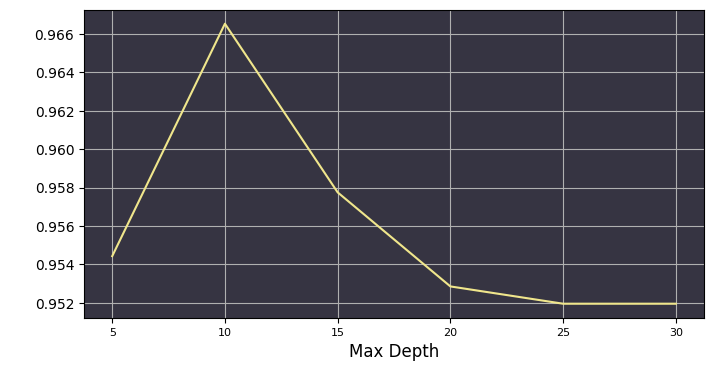

In [94]:
figure_labels=['5', '10' ,'15' ,'20' ,'25' ,'30']

plt.figure(figsize = (8,4))
plt.rcParams ['axes.facecolor'] = '#363442'
plt.plot(figure_labels, accuracy_dt, color='khaki')
plt.xlabel('Max Depth', color = 'black', size = 12)
plt.ylabel('Accuracy', color = 'white', size = 14)
plt.xticks(color = 'black', size = 8)
plt.grid()

plt.plot()

**Plotting Decision Tree accuracy with different max Bins**


In [95]:
# Decision Tree Classifier - Different Max Bins

accuracies_dt = list()

for i in range(25, 71, 5):
  decision_tree = DecisionTreeClassifier(labelCol="indexed_class", featuresCol="features" , maxDepth = 10 , maxBins = i)
  # Create a new pipeline with VectorAssembler and DecisionTreeClassifier
  pipeline_dt = Pipeline(stages=[vector_assembler, decision_tree])
  # Fit the pipeline on the training data
  model_dt = pipeline_dt.fit(train_data)
  # Make predictions on the test data
  predictions_dt = model_dt.transform(test_data)

  # Computing evaluation metrics for Decision Tree : Accuracy
  evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
  accuracies_dt.append(evaluator.evaluate(predictions_dt))

accuracies_dt

[0.9683997070917592,
 0.9666535233481665,
 0.9675547794738918,
 0.9666535233481665,
 0.9667661803638822,
 0.9672731369346026,
 0.9673857939503182,
 0.9659212527460148,
 0.9683433785839013,
 0.9674984509660339]

[]

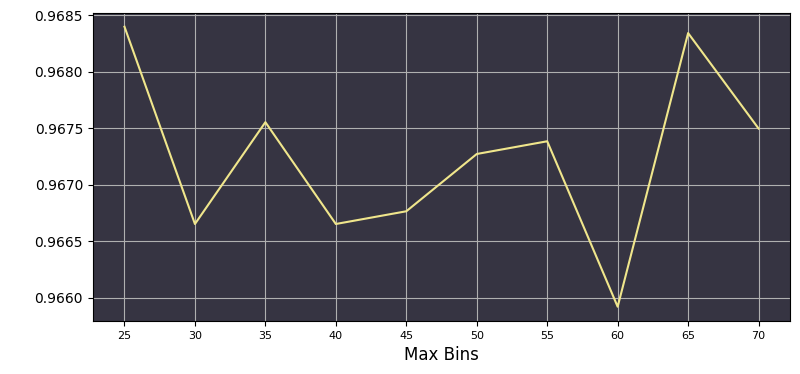

In [96]:
figure_labels=['25', '30' ,'35' ,'40' ,'45' ,'50' ,'55' ,'60' ,'65' ,'70']

plt.figure(figsize = (9,4))
plt.rcParams ['axes.facecolor'] = '#363442'
plt.plot(figure_labels, accuracies_dt, color='khaki')
plt.xlabel('Max Bins', color = 'black', size = 12)
plt.ylabel('Accuracy', color = 'white', size = 14)
plt.xticks(color = 'black', size = 8)
plt.grid()

plt.plot()

 **Finding the best combination of " max Bins " and  " max Depth " for Decision Tree**

I used K-Fold Cross Validation to find the best combination of these two Hyperparameters.
( After I found the best set of values, I commented that out because it takes quite a while to execute this section)

The result is :


*   Best maxDepth value: 10
*   Best maxBins  value: 80

*   Accuracy : 97.09 %

In [97]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Define the DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(labelCol="indexed_class", featuresCol="features")

# Create a new pipeline with VectorAssembler and DecisionTreeClassifier
pipeline_dt = Pipeline(stages=[vector_assembler, decision_tree])

# Define the parameter grid for maxBins and maxDepth
param_grid = (ParamGridBuilder()
    .addGrid(decision_tree.maxBins, range(70, 91, 10))
    .addGrid(decision_tree.maxDepth, range(10, 16, 5))
    .build())


# Create the cross-validator
cross_validator = CrossValidator(estimator=pipeline_dt,
                                estimatorParamMaps=param_grid,
                                evaluator=MulticlassClassificationEvaluator(labelCol="indexed_class",
                                                                            predictionCol="prediction",
                                                                            metricName="accuracy"),
                                numFolds=5)  # Set the number of folds for cross-validation

# Fit the cross-validator on the training data
cv_model = cross_validator.fit(train_data)

# Get the best model from cross-validation
best_model = cv_model.bestModel

# Get the best maxBins and maxDepth values from the best model
best_maxBins = best_model.stages[-1].getMaxBins()
best_maxDepth = best_model.stages[-1].getMaxDepth()

# Print the best maxBins and maxDepth values
print("Best maxBins value: ", best_maxBins)
print("Best maxDepth value: ", best_maxDepth)

# Use the best model to make predictions on the test data
predictions_dt = best_model.transform(test_data)

# Compute evaluation metrics for Decision Tree: Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class",
                                              predictionCol="prediction",
                                              metricName="accuracy")
accuracy = evaluator.evaluate(predictions_dt)

# Print the accuracy
print("Accuracy: {:.2%}".format(accuracy))


**Building the Decision Tree model with the best Hyperparameters**

In [98]:
# Decision Tree Classifier knowing the best maxDepth and maxBins
decision_tree = DecisionTreeClassifier(labelCol="indexed_class", featuresCol="features" , maxDepth=10 , maxBins=80)

# Create a pipeline with VectorAssembler and DecisionTreeClassifier
pipeline_dt = Pipeline(stages=[vector_assembler, decision_tree])

# Fit the pipeline on the training data
model_dt = pipeline_dt.fit(train_data)

# Make predictions on the test data
predictions_dt = model_dt.transform(test_data)

# Compute evaluation metrics for Decision Tree : Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_dt)

print("Accuracy: {:.2%}".format(accuracy))

Accuracy: 96.86%


**Precision, Recall and F1-score - Decision Tree**

In [99]:
# Decision Tree - Computing evaluation metrics : precision, recall and F1-score

predictionAndLabels = predictions_dt.select("prediction", "indexed_class").rdd
metrics = MulticlassMetrics(predictionAndLabels)
labels = predictionAndLabels.map(lambda x: x[1]).distinct().collect()

print("Decision Tree - Reminder : Class: 0 Means GALAXY , Class: 1 Means STAR , Class: 2 Means QSO \n")
for label in labels:
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    f1Score = metrics.fMeasure(label)

    print("Class: ", label)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1-Score: ", f1Score ,"\n")

/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:157: FutureWarning:

Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.



Decision Tree - Reminder : Class: 0 Means GALAXY , Class: 1 Means STAR , Class: 2 Means QSO 

Class:  0.0
Precision:  0.9703785435409947
Recall:  0.9823852895686545
F1-Score:  0.9763450042698548 

Class:  1.0
Precision:  0.9850071394574013
Recall:  0.9890083632019115
F1-Score:  0.9870036961964945 

Class:  2.0
Precision:  0.9180327868852459
Recall:  0.8414507772020725
F1-Score:  0.8780751554474181 



**Confusion Matrix - Decision Tree**

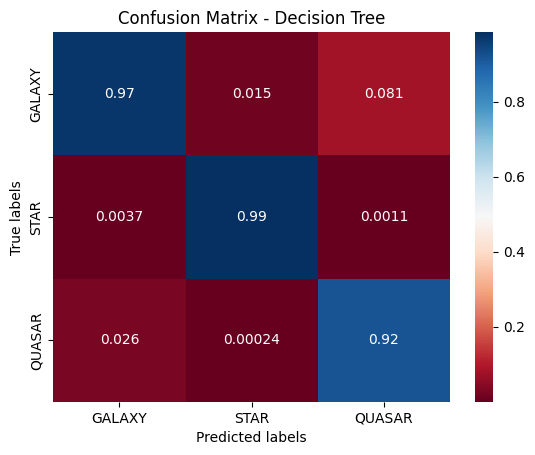

In [100]:
# Confusion Matrix (in %) - Decision Tree
predictionAndLabels_dt = predictions_dt.select("prediction", "indexed_class").rdd.map(lambda row: (row.prediction, float(row.indexed_class)))
metrics_dt = MulticlassMetrics(predictionAndLabels_dt)
confumx_dt = metrics_dt.confusionMatrix()
confuarr_dt = confumx_dt.toArray()
confusionmatrix_dt = pd.DataFrame(confuarr_dt.astype(float))
ax_dt = plt.subplot()
sb.heatmap(confusionmatrix_dt/np.sum(confusionmatrix_dt), annot=True, cmap='RdBu')
ax_dt.set_xlabel("Predicted labels")
ax_dt.set_ylabel("True labels")
ax_dt.set_title("Confusion Matrix - Decision Tree")
ax_dt.xaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
ax_dt.yaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
plt.show()

**AUC - Decision Tree**

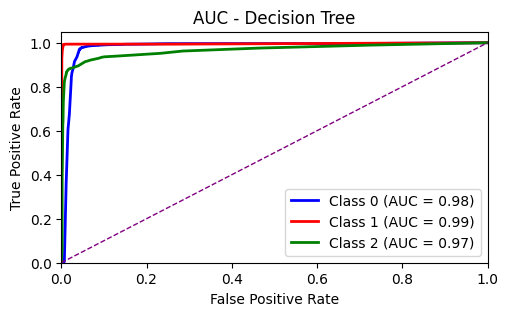

In [101]:
# Convert DataFrame to Pandas for computing ROC curve
predictions_pd = predictions_dt.select('indexed_class', 'probability').toPandas()

# Compute ROC curve and AUC for each class
n_classes = len(predictions_pd['indexed_class'].unique())
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    true_labels = (predictions_pd['indexed_class'] == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(true_labels, predictions_pd['probability'].apply(lambda x: float(x[i])))
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(5.5, 3) )
plt.rcParams ['axes.facecolor'] = 'white'
colors = ['blue', 'red', 'green']  # Customize colors for each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='purple', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC - Decision Tree')
plt.legend(loc='lower right')
plt.show()

**Feature Importance - Desision Tree**

In [102]:
# I want to know the importance of each feature in predictions in Decision Tree

pipeline_model = pipeline_dt.fit(indexed_DF)

# Get the trained Decision Tree model
model = pipeline_model.stages[-1]

# Retrieve feature importances from the model
importances = model.featureImportances.toArray()
importances = [float(x) for x in importances]

# Create a DataFrame to store feature names and importances
feature_importance_df = spark.createDataFrame(zip(indexed_DF.columns[:-1], importances), ['Feature', 'Importance_Decision Tree'])

# Specify the data type of the 'Importance' field
feature_importance_df = feature_importance_df.withColumn('Importance_Decision Tree', feature_importance_df['Importance_Decision Tree'].cast(FloatType()))

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.orderBy('Importance_Decision Tree', ascending=False)

# Show the feature importances
feature_importance_df.show()

+--------+------------------------+
| Feature|Importance_Decision Tree|
+--------+------------------------+
|redshift|               0.9000268|
|       g|             0.050193287|
|       u|              0.01698959|
|       z|             0.010623455|
|       i|            0.0063148052|
|   plate|            0.0059008766|
|       r|             0.003375601|
|   alpha|            0.0023328583|
|     MJD|            0.0022482479|
|   delta|            0.0019944534|
+--------+------------------------+



**Logistic Regression**

In [103]:
# Logistic Regression

# Specify the feature columns
feature_columns = [ 'alpha' , 'delta' ,  'u' , 'g' , 'r' ,  'i' , 'z'  , 'redshift' , 'plate' , 'MJD' ]

# Create a VectorAssembler to combine the feature columns into a single vector column
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Create a StandardScaler instance to scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

# Create a LogisticRegression instance
logistic_regression = LogisticRegression(labelCol="indexed_class", featuresCol="scaled_features" )

# Create a pipeline with VectorAssembler, StandardScaler, and LogisticRegression
pipeline_lr = Pipeline(stages=[vector_assembler, scaler, logistic_regression])

# Fit the pipeline on the training data
model_lr = pipeline_lr.fit(train_data)

# Make predictions on the test data
predictions_lr = model_lr.transform(test_data)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(labelCol="indexed_class", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_lr)
print("Accuracy: {:.2%}".format(accuracy))

Accuracy: 96.23%



**Precision, Recall and F1-score - Logistic Regression**


In [104]:
# Logistic Regression - Computing evaluation metrics : precision, recall and F1-score

predictionAndLabels = predictions_lr.select("prediction", "indexed_class").rdd
metrics = MulticlassMetrics(predictionAndLabels)
labels = predictionAndLabels.map(lambda x: x[1]).distinct().collect()

print("Logistic Regression - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO \n")
for label in labels:
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    f1Score = metrics.fMeasure(label)

    print("Class: ", label)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1-Score: ", f1Score ,"\n")

/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:157: FutureWarning:

Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.



Logistic Regression - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO 

Class:  0.0
Precision:  0.9647517369937298
Recall:  0.9783467949819556
F1-Score:  0.9715017064846415 

Class:  1.0
Precision:  0.9757462686567164
Recall:  0.9997610513739545
F1-Score:  0.9876076950312758 

Class:  2.0
Precision:  0.9104028863499699
Recall:  0.7844559585492228
F1-Score:  0.8427497912607848 



**Confusion Matrix - Logistic Regression**

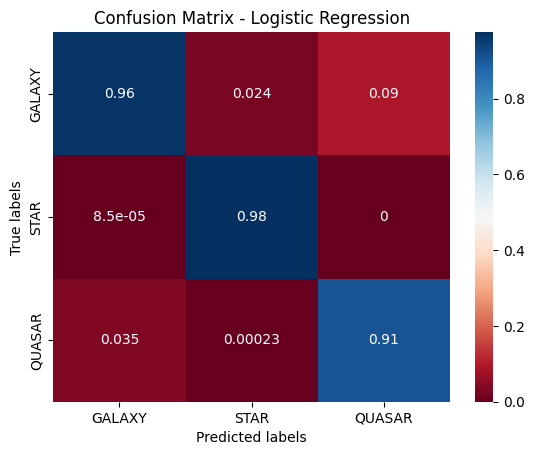

In [105]:
# Confusion Matrix (in %) - Logistic Regression
predictionAndLabels_lr = predictions_lr.select("prediction", "indexed_class").rdd.map(lambda row: (row.prediction, float(row.indexed_class)))
metrics_lr = MulticlassMetrics(predictionAndLabels_lr)
confumx_lr = metrics_lr.confusionMatrix()
confuarr_lr = confumx_lr.toArray()
confusionmatrix_lr = pd.DataFrame(confuarr_lr.astype(float))
ax_lr = plt.subplot()
sb.heatmap(confusionmatrix_lr/np.sum(confusionmatrix_lr), annot=True, cmap='RdBu')
ax_lr.set_xlabel("Predicted labels")
ax_lr.set_ylabel("True labels")
ax_lr.set_title("Confusion Matrix - Logistic Regression")
ax_lr.xaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
ax_lr.yaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
plt.show()

**AUC - Logistic Regression**

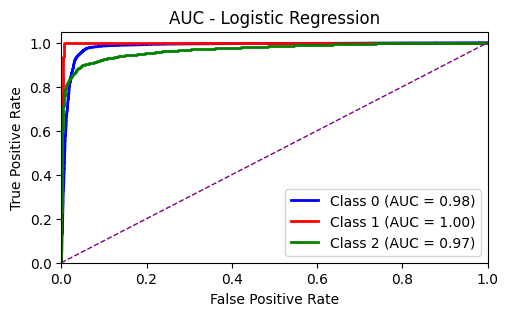

In [106]:
# Convert DataFrame to Pandas for computing ROC curve
predictions_pd = predictions_lr.select('indexed_class', 'probability').toPandas()

# Compute ROC curve and AUC for each class
n_classes = len(predictions_pd['indexed_class'].unique())
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    true_labels = (predictions_pd['indexed_class'] == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(true_labels, predictions_pd['probability'].apply(lambda x: float(x[i])))
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(5.5, 3) )
plt.rcParams ['axes.facecolor'] = 'white'
colors = ['blue', 'red', 'green']  # Customize colors for each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='purple', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

**SVC**

In [107]:
# SVC ( Support Vector Classifier )

# Create a StandardScaler instance to scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

# Create a StringIndexer to convert the "indexed_class" column into numeric labels
labelIndexer = StringIndexer(inputCol="indexed_class", outputCol="label")

# Create a LinearSVC model with One-vs-Rest (OvR) strategy
svc = LinearSVC(maxIter=10, regParam=0.1)

# Create a OneVsRest model with LinearSVC as the base classifier
ovr = OneVsRest(classifier=svc)

# Create a pipeline with the stages
pipeline_svc = Pipeline(stages=[vector_assembler, labelIndexer, ovr])

# Fit the pipeline on the training data
model_svc = pipeline_svc.fit(train_data)

# Make predictions on the test data
predictions_svc = model_svc.transform(test_data)

# Evaluate the model
evaluator_svc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_svc = evaluator_svc.evaluate(predictions_svc)
print("Accuracy: {:.2%}".format(accuracy_svc))

Accuracy: 82.21%


**Precision, Recall and F1-score - SVC**

In [108]:
# SVC - Computing evaluation metrics : precision, recall and F1-score

predictionAndLabels_svc = predictions_svc.select("prediction", "indexed_class").rdd
metrics = MulticlassMetrics(predictionAndLabels)
labels = predictionAndLabels_svc.map(lambda x: x[1]).distinct().collect()

print(" SVC - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO \n")
for label in labels:
    precision = metrics.precision(label)
    recall = metrics.recall(label)
    f1Score = metrics.fMeasure(label)

    print("Class: ", label)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1-Score: ", f1Score ,"\n")

/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:157: FutureWarning:

Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.



 SVC - Reminder : Class: 0 -> GALAXY , Class: 1 -> STAR , Class: 2 -> QSO 

Class:  0.0
Precision:  0.9647517369937298
Recall:  0.9783467949819556
F1-Score:  0.9715017064846415 

Class:  1.0
Precision:  0.9757462686567164
Recall:  0.9997610513739545
F1-Score:  0.9876076950312758 

Class:  2.0
Precision:  0.9104028863499699
Recall:  0.7844559585492228
F1-Score:  0.8427497912607848 



**Confusion Matrix - SVC**

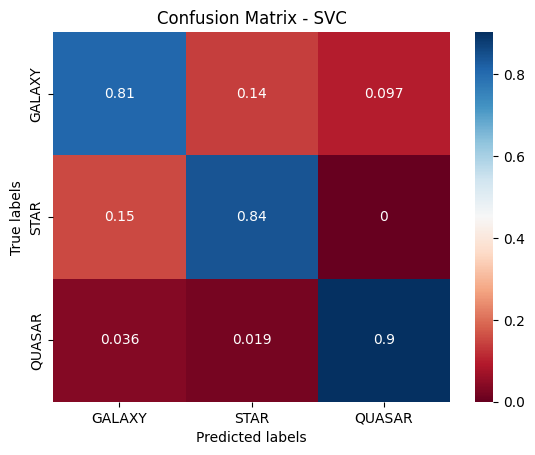

In [109]:
# Confusion Matrix (in %) - SVC
predictionAndLabels_svc = predictions_svc.select("prediction", "indexed_class").rdd.map(lambda row: (row.prediction, float(row.indexed_class)))
metrics_svc = MulticlassMetrics(predictionAndLabels_svc)
confumx_svc = metrics_svc.confusionMatrix()
confuarr_svc = confumx_svc.toArray()
confusionmatrix_svc = pd.DataFrame(confuarr_svc.astype(float))
ax_svc = plt.subplot()
sb.heatmap(confusionmatrix_svc/np.sum(confusionmatrix_svc), annot=True, cmap='RdBu')
ax_svc.set_xlabel("Predicted labels")
ax_svc.set_ylabel("True labels")
ax_svc.set_title("Confusion Matrix - SVC")
ax_svc.xaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
ax_svc.yaxis.set_ticklabels(["GALAXY", "STAR", "QUASAR"])
plt.show()

**AUC - SVC**

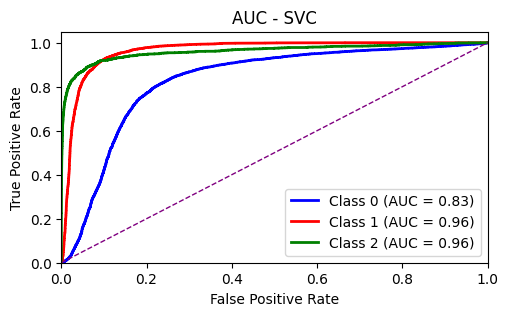

In [110]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
from pyspark.ml.linalg import DenseVector

# Convert DataFrame to Pandas for computing ROC curve
predictions_pd = predictions_svc.select('indexed_class', 'rawPrediction').toPandas()

# Compute probabilities from raw predictions
predictions_pd['probability'] = predictions_pd['rawPrediction'].apply(lambda x: DenseVector(x).toArray())

# Compute ROC curve and AUC for each class
n_classes = len(predictions_pd['indexed_class'].unique())
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    true_labels = (predictions_pd['indexed_class'] == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(true_labels, predictions_pd['probability'].apply(lambda x: float(x[i])))
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(5.5, 3))
plt.rcParams['axes.facecolor'] = 'white'
colors = ['blue', 'red', 'green']  # Customize colors for each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], color='purple', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC - SVC')
plt.legend(loc='lower right')
plt.show()